# Overview of seaborn plotting functions ⭐

📄 Source: https://seaborn.pydata.org/tutorial/function_overview.html

The key page for understanding where **seaborn stops and matplotlib takes over**: axes-level vs figure-level functions.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
print("seaborn", sns.__version__)

seaborn 0.13.2


## Similar functions for similar tasks

The namespace is flat (`sns.anything`), but the functions are grouped into **modules** with similar goals: *relational*, *distributional*, *categorical*.
For example, the distributions module has the histogram:

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

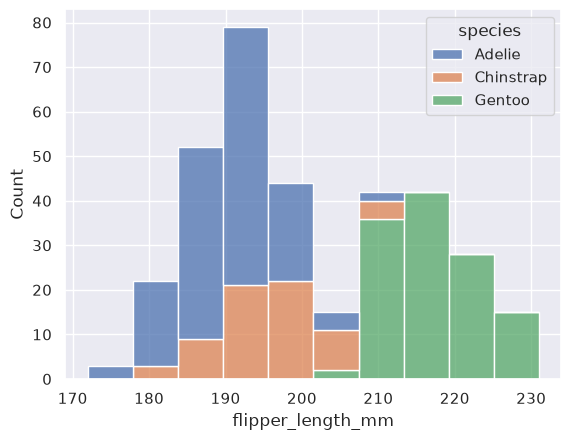

In [2]:
penguins = sns.load_dataset("penguins")
sns.histplot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")   # stacked histogram

...and the kernel density estimate:

<Axes: xlabel='flipper_length_mm', ylabel='Density'>

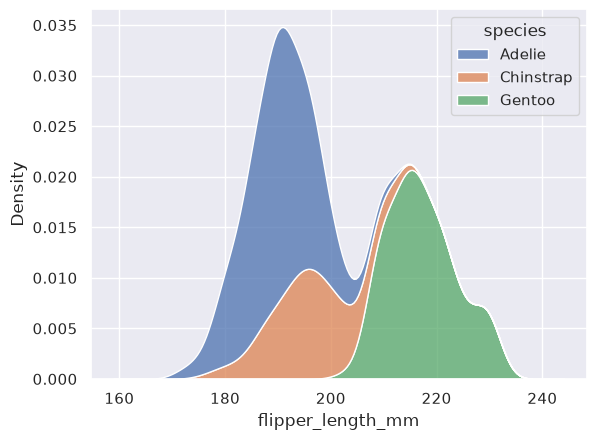

In [3]:
sns.kdeplot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")   # same arguments, KDE instead

Functions in one module share code and features (like `multiple="stack"` above), so you can switch between representations easily while exploring.

## Figure-level vs. axes-level functions

A second classification cuts across the modules:

- **Axes-level** functions (the examples above) draw onto **one matplotlib `Axes`** and return it.
- **Figure-level** functions manage a whole figure through a seaborn object, usually a `FacetGrid`. Each module has one, offering all its axes-level functions through `kind=`:

| Figure-level (module) | Axes-level functions it wraps (`kind=`) |
| :-- | :-- |
| **`relplot`** (relational) | `scatterplot`, `lineplot` |
| **`displot`** (distributions) | `histplot`, `kdeplot`, `ecdfplot`, `rugplot` |
| **`catplot`** (categorical) | `stripplot`, `swarmplot`, `boxplot`, `violinplot`, `pointplot`, `barplot` |

`displot` draws a histogram by default, using the same code as `histplot`:

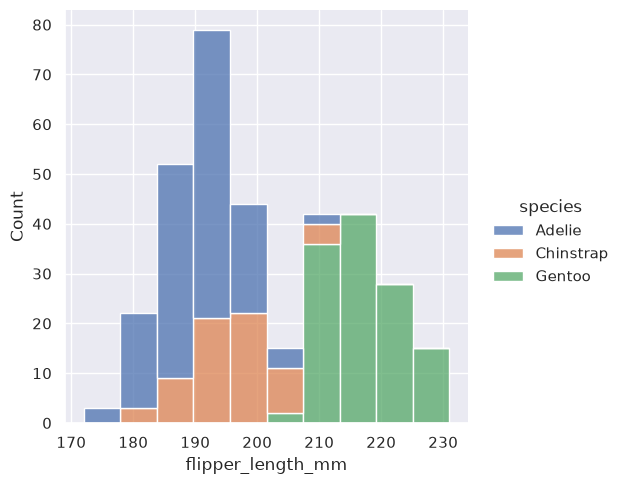

In [4]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")

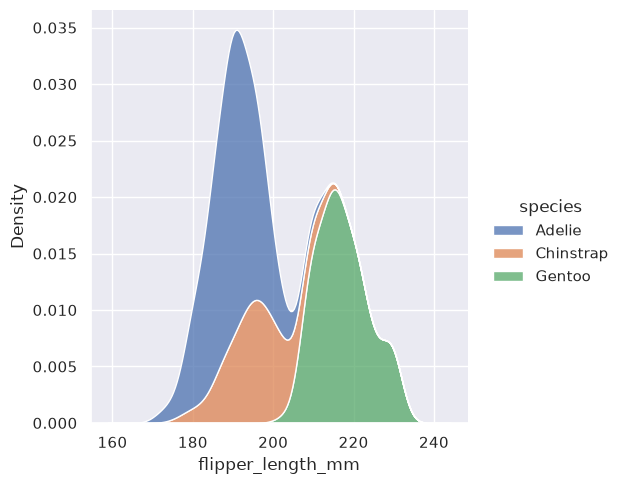

In [5]:
# kind="kde" uses the same code as kdeplot
sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack", kind="kde")

Figure-level plots look almost the same, but the **legend is outside** the plot and the shape is a bit different.
Their best feature: **faceting**, i.e. one subplot per value of a variable:

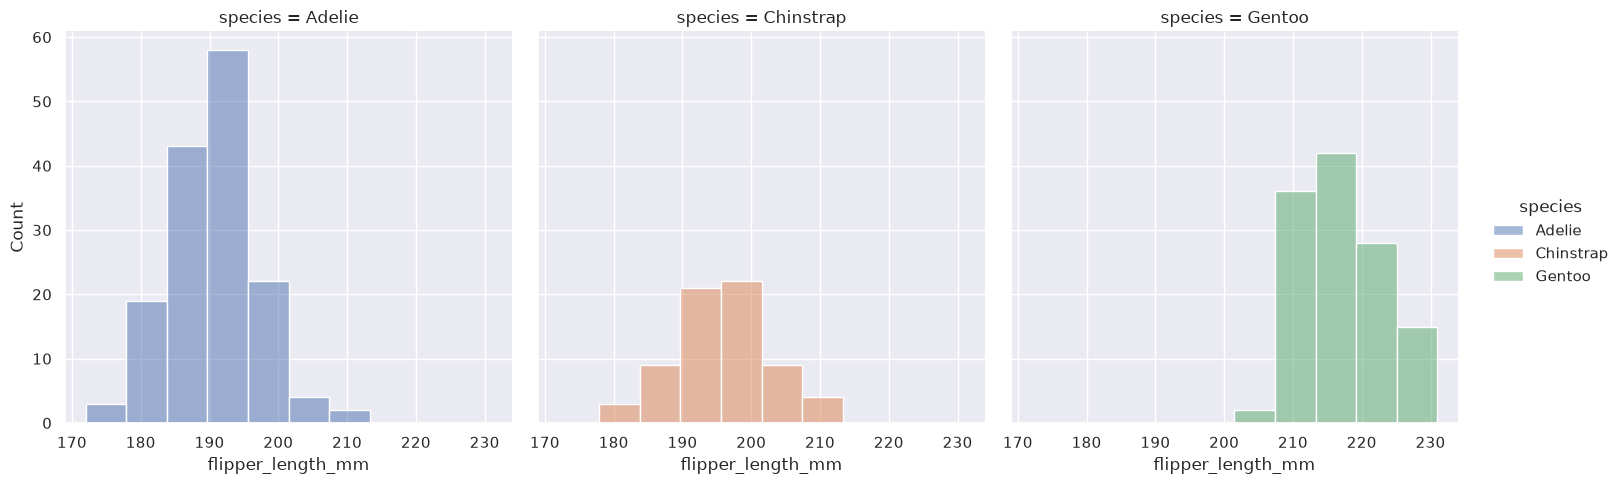

In [6]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", col="species")   # one column per species

Figure-level functions pass kind-specific arguments (e.g. histogram `bins`) down to the axes-level function. Downside: those parameters are **not in the figure-level signature/docstring**, so you may need to read two doc pages.

### Axes-level functions make self-contained plots

Axes-level functions behave like **drop-in replacements for matplotlib functions**. They add labels and legends but change nothing outside their Axes, so you can combine them into any matplotlib figure.
They draw on the "current" Axes (`plt.gca()`) by default, but also accept **`ax=`**, which plugs into the OO interface:

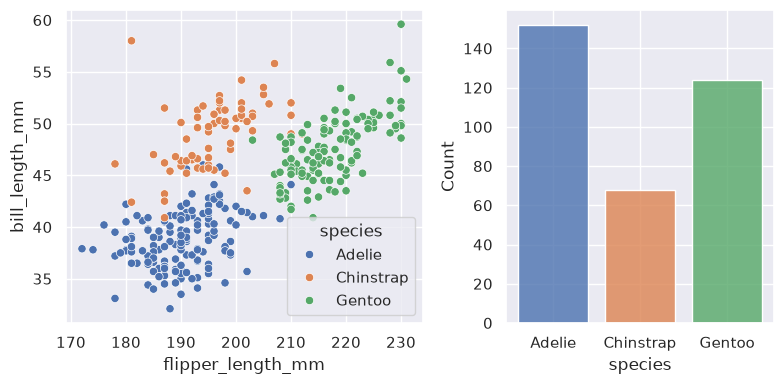

In [7]:
f, axs = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw=dict(width_ratios=[4, 3]))   # matplotlib makes the layout
sns.scatterplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species", ax=axs[0])  # seaborn fills the left Axes
sns.histplot(data=penguins, x="species", hue="species", shrink=.8, alpha=.8, legend=False, ax=axs[1])  # and the right one
f.tight_layout()

### Figure-level functions own their figure

They can't (easily) be drawn into an existing Axes: they create their own figure. But you can reach the matplotlib Axes on the returned object and add things:

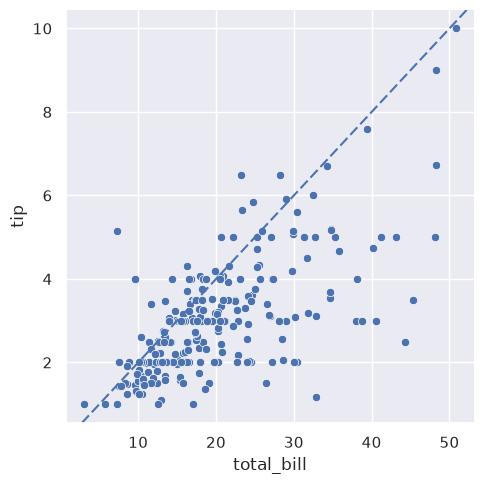

In [8]:
tips = sns.load_dataset("tips")
g = sns.relplot(data=tips, x="total_bill", y="tip")
g.ax.axline(xy1=(10, 2), slope=.2, color="b", dashes=(5, 2))   # g.ax = the matplotlib Axes (single-panel grid)

### Customizing plots from a figure-level function

They return a `FacetGrid`, whose methods are "smart" about the subplot layout. E.g. relabel the outer axes in one line:

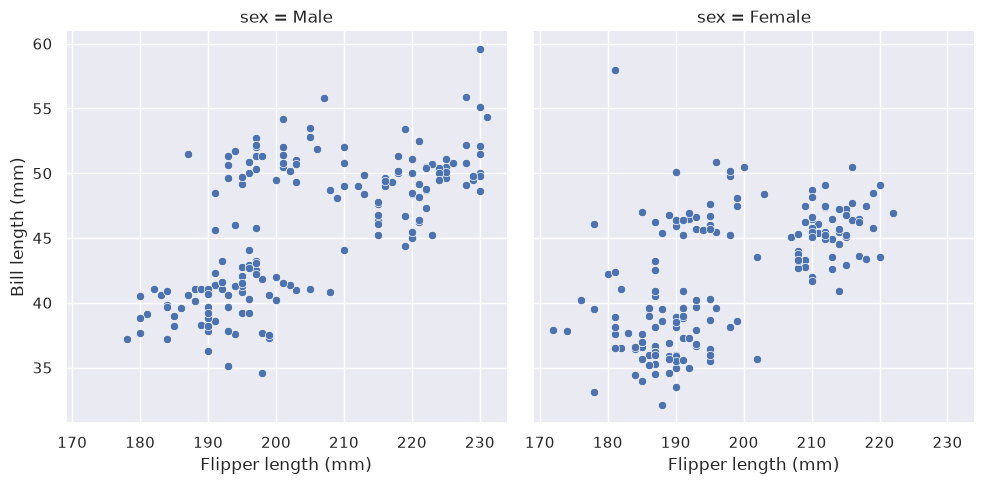

In [9]:
g = sns.relplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", col="sex")
g.set_axis_labels("Flipper length (mm)", "Bill length (mm)")   # applied to all panels at once

Convenient, but remember: `set_axis_labels` is **seaborn's** API (FacetGrid), not matplotlib's.

### Specifying figure sizes

In matplotlib you size the **whole figure** (`figsize=`, rcParams, `set_size_inches`). Axes-level seaborn functions follow the same rules.

Figure-level functions are different:
1. they have their own size parameters: **`height`** and **`aspect`** (really FacetGrid parameters), with `width = height * aspect`;
2. these size **each subplot**, not the whole figure.

Default `plt.subplots()` with one subplot:

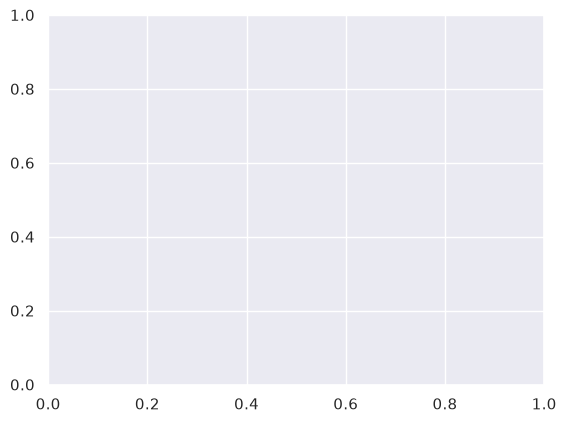

In [10]:
f, ax = plt.subplots()

More columns → same overall figure size, so the Axes get squeezed:

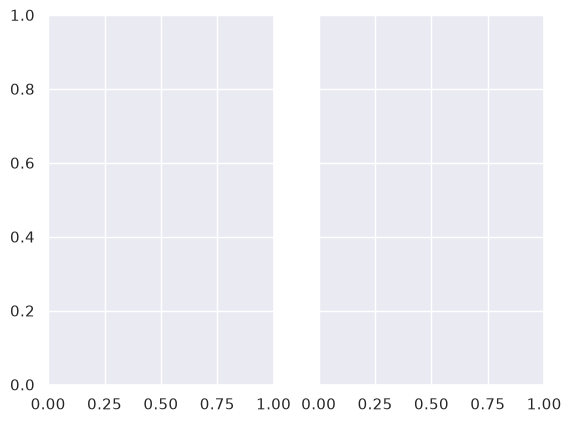

In [11]:
f, ax = plt.subplots(1, 2, sharey=True)

A figure-level function (shown here with an empty `FacetGrid`, which is what `relplot`/`displot`/`catplot` build behind the scenes) gives a **square** subplot:

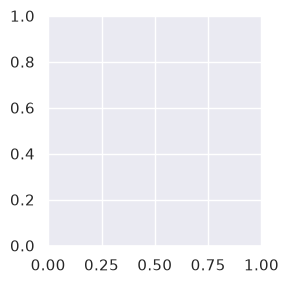

In [12]:
g = sns.FacetGrid(penguins)

Adding columns makes the **figure wider**, so every subplot keeps the same size and shape:

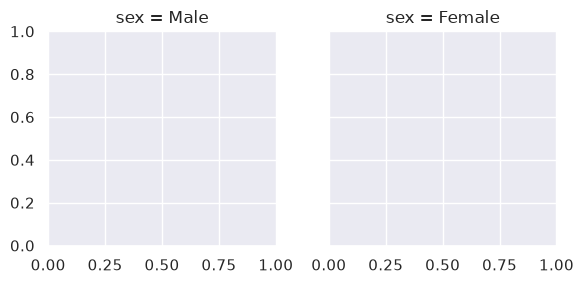

In [13]:
g = sns.FacetGrid(penguins, col="sex")

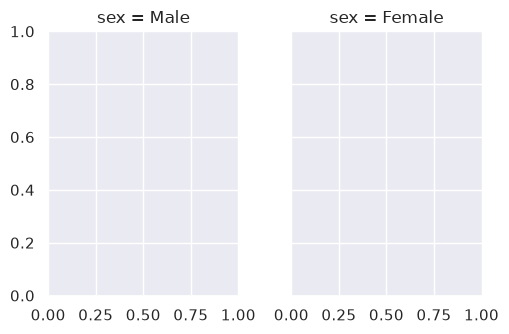

In [14]:
# Change each subplot's size/shape without thinking about rows/columns
g = sns.FacetGrid(penguins, col="sex", height=3.5, aspect=.75)

So you can add facets without resizing the figure. But when you do want a specific size, remember it works differently than matplotlib.

### Relative merits of figure-level functions

| Advantages | Drawbacks |
| :-- | :-- |
| Easy faceting by data variables | Many parameters not in function signature |
| Legend outside of plot by default | Cannot be part of a larger matplotlib figure |
| Easy figure-level customization | Different API from matplotlib |
| Different figure size parameterization | Different figure size parameterization |

The docs recommend figure-level functions for most uses. **Exception:** a complex standalone figure that combines different plot kinds. Then build the layout with matplotlib and fill each Axes with axes-level functions (`ax=`).

## Combining multiple views on the data

`jointplot` and `pairplot` don't fit the scheme: they combine plots from different modules. Both are figure-level and use `JointGrid` and `PairGrid`.

`jointplot`: one relationship + the marginal distribution of each variable:

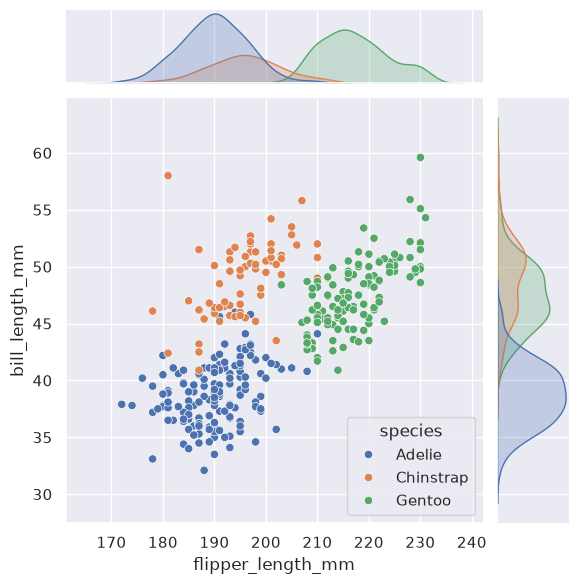

In [15]:
sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species")

`pairplot`: every pairwise combination at once:

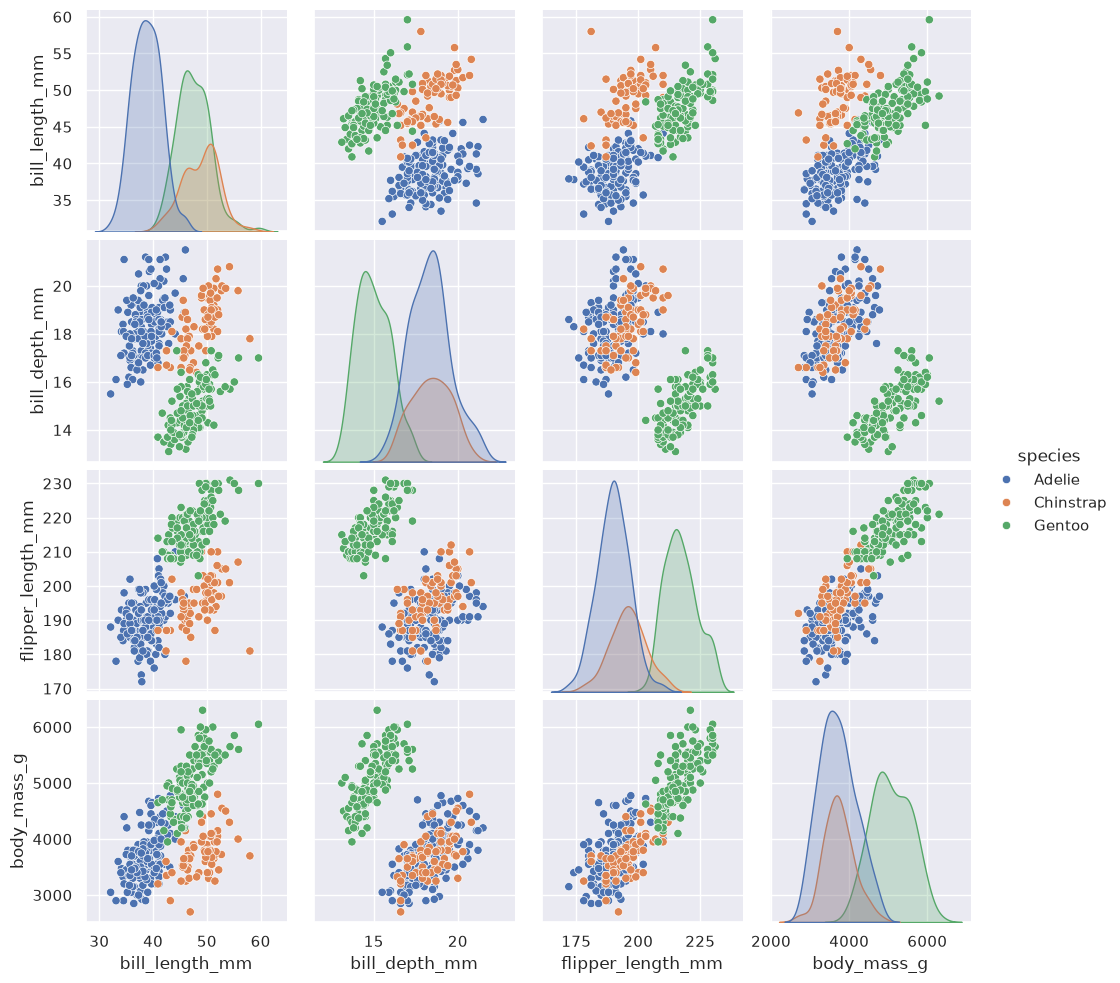

In [16]:
sns.pairplot(data=penguins, hue="species")

They use `scatterplot` and `kdeplot` behind the scenes, and have a `kind` parameter too:

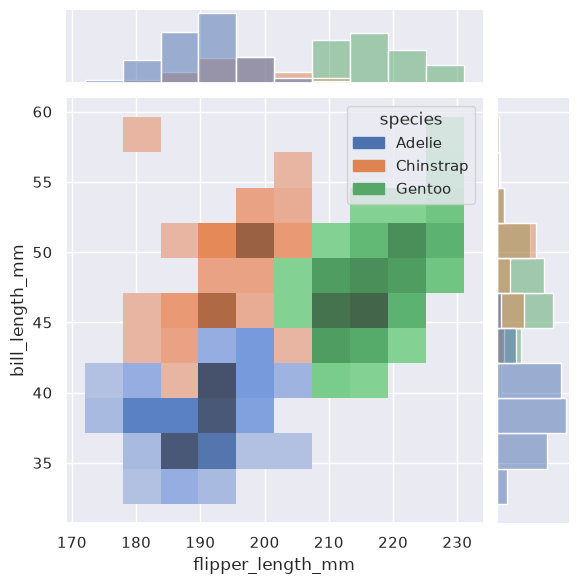

In [17]:
sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species", kind="hist")

## Exercise (from the README): the seaborn/matplotlib boundary

Draw the same histogram (1) with an axes-level function inside **my** `fig, ax`, and (2) with a figure-level function. Then change the title in both.

Text(0.5, 1.0, 'Axes-level: ax.set_title()')

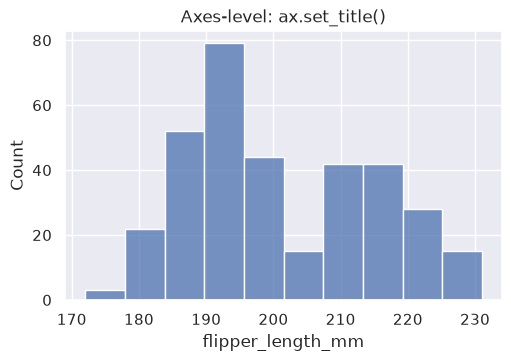

In [18]:
# 1) Axes-level: I own the figure, seaborn draws into my ax
fig, ax = plt.subplots(figsize=(5, 3.5), layout="constrained")
sns.histplot(data=penguins, x="flipper_length_mm", ax=ax)   # returns the same ax
ax.set_title("Axes-level: ax.set_title()")                  # plain matplotlib

<class 'seaborn.axisgrid.FacetGrid'> | figure: Figure | axes array shape: (1, 1)


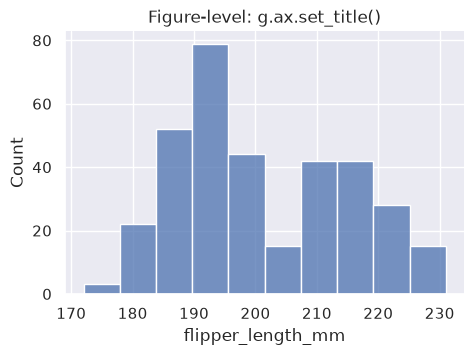

In [19]:
# 2) Figure-level: seaborn owns the figure and returns a FacetGrid
g = sns.displot(data=penguins, x="flipper_length_mm", height=3.5, aspect=1.4)
g.ax.set_title("Figure-level: g.ax.set_title()")   # reach matplotlib through g.ax
# with facets you would use g.set_titles("{col_name}") or loop over g.axes.flat
print(type(g), "| figure:", type(g.figure).__name__, "| axes array shape:", g.axes.shape)

## Key takeaways

- **Axes-level** (`scatterplot`, `histplot`, `boxplot`...): take `ax=`, return the `Axes`, fit into your `fig, ax`.
- **Figure-level** (`relplot`, `displot`, `catplot`, `lmplot`, `jointplot`, `pairplot`): create their own figure, return a grid `g`; use `g.figure`, `g.ax` / `g.axes`.
- Size figure-level plots with `height=` and `aspect=` (per subplot), not `figsize`.
- Complex multi-kind figure → matplotlib layout + axes-level functions.